<a href="https://colab.research.google.com/github/sashavlasits/Data-Science/blob/main/Unit8/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decisions tree is just a set of binary decisions that split a data set into chunks. The nodes of the tree decide the division points for the chunks based on the predicted variable. Then the data is made into various buckets of predictor values. This then gives us a sense of how the predictor affects the predicted thing.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decicion tree means how many layers of nodes it contains, and thus how many times the data is "split." You can tell if the tree is too deep by looking at the posterior predictive to check for overfitting, which basically just causes the dots to look connected. For a too shallow tree, the model will underfit.

**Task4:**

How are BART models similar and different from a decision tree?

BART models are similar to a decsiions tree in that they are decision trees! However, they are a whole bunch of decisions trees, which is a big difference. But they are more than just a bunch of trees next to each other because the trees based themselves off of the other trees in the forest.

**Task5**:

Why would we use a BART model instead of a decision tree?

We use BART models instead of decisions trees because they are more likely to pick up on multiple patters and nuances in the data due to the large amount of trees involved. The trees all also work together in BART models, which improves the accuracy even further. Finally, the fact that the individual trees in the forest of a BART model are all relatively shallow, so the risk of overfitting is much lower.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [5]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


In [6]:
#Combine all my estimator variables into one dataframe
X = penguins[[
             'flipper_length',
             'bill_length',
             'bill_depth',
             ]]
#Define my estimand as Y
Y = penguins['body_mass']

In [ ]:
with pm.Model() as model_penguin:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_penguins = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_penguins, model_penguin, extend_inferencedata=True)


<Axes: xlabel='y'>

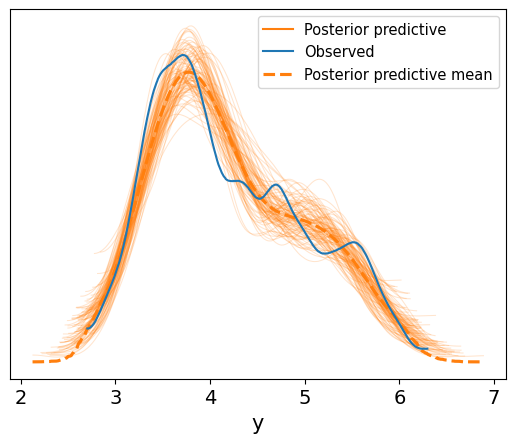

In [20]:
az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [10]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


[Text(0.5, 1.0, 'Posterior Predictive'),
 Text(0.5, 0, 'flipper length'),
 Text(0, 0.5, 'body mass')]

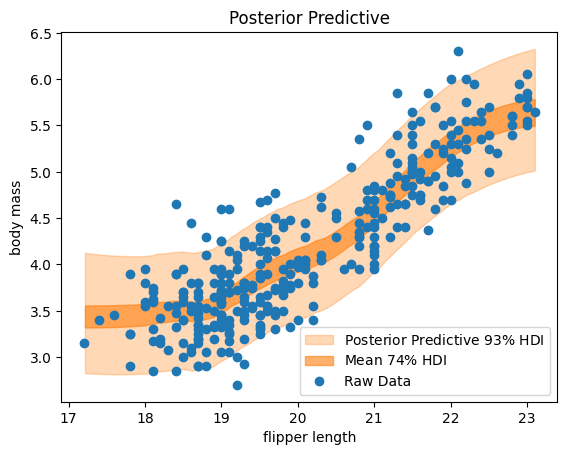

In [14]:
##gemeni helped me fix and error or two
idx = np.argsort(X.iloc[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.iloc[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.iloc[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper length",
    ylabel="body mass"
)

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

The plot above is showing a general positive linear corellation between flipper length and body mass, though it shows that the trend flattens out for extreme high and low values of flipper length. I think that, based on my own high knowledge of data science penguin stuff, that this is capturing the right trend in the data, though I do question the aforementioned flatness. This is really not shown in the data at all, but other than that, I think it's doing great.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_length'>,
       <Axes: xlabel='bill_depth'>], dtype=object)

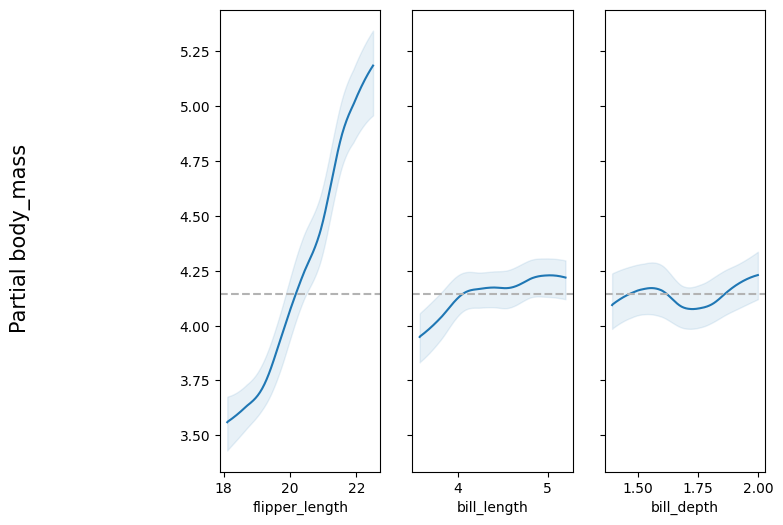

In [15]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_length'>,
       <Axes: xlabel='bill_depth'>], dtype=object)

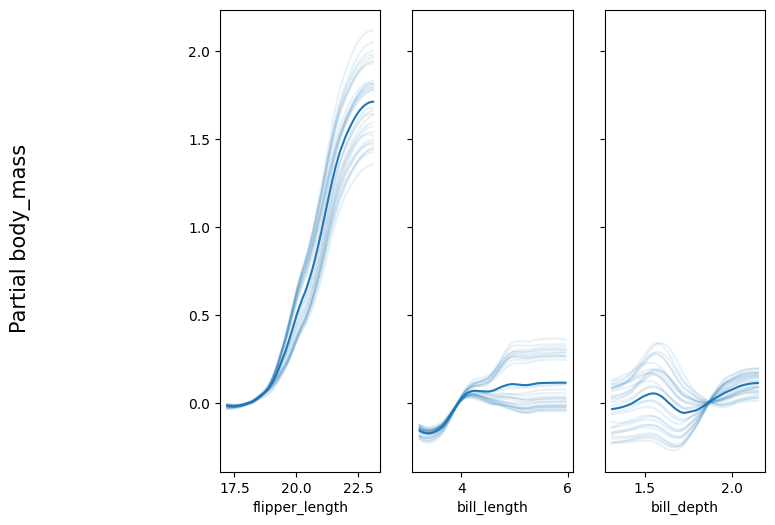

In [16]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [17]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, μ_, X)

<Axes: ylabel='R²'>

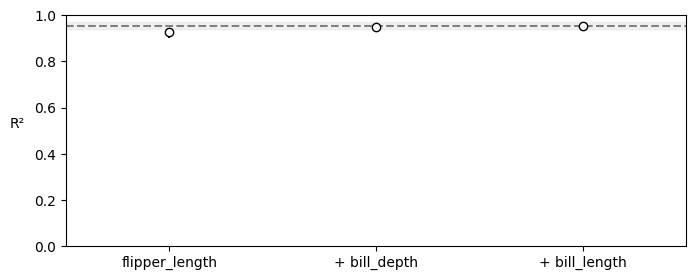

In [18]:
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Based on the above plots, it sure seems like flipper length is the most important variable in predicting body mass in penguins. In both the pdp and ice plots it is shown to have a very strong positive linear correlation with body mass that doesn't seem to vary very much in the ice plot. It is also shown to have an incredibly high r squared value, though that also seems to be the case for the other variables.

Flipper length has a very strong relationship with body mass with pretty minimal variance when taking the other variables into account. With bill length there is a storng positive linear correlltion up to a certain value where it plateaus. However, in the ice plot, the value of body mass at which it plateaus varies quite a bit. For bill depth the overall trend is pretty flat with slight positive trend for low and high length values and a slight negative trend for medium values.

The variables are sort of complicated by the interactions between the variables, as well can see from a few cases of non parallel lines on the ice plots, but it doesn't look to be that bad to me. This is espeically seen in the bill depth plot, where this lack of parallellness is present for most values on the plot. This makes sense because bill deptth likely interacts a great deal with the bill length vairable, since they are measuring very similar things.